<a href="https://colab.research.google.com/github/su-sumico/seminar/blob/main/Factor_SDGs_E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

因子分析/factor analysis
* reference: https://qiita.com/y_itoh/items/227cb33317ceb09199c2
* reference: https://www.nttcoms.com/service/research/dataanalysis/factor-analysis/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 数値計算ライブラリ/Numerical calculation library
import numpy as np
import pandas as pd
# 可視化ライブラリ/Visualization library
import matplotlib.pyplot as plt
%matplotlib inline

データを読み込みます/Load data

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/unsp/Factor_SDGs_E.csv",encoding = "shift-jis")
df.head()

,ＩＤ,"Basically, I try to be nice to all people.",I'm pretty good at pacing myself to get things done on time.,I really enjoy talking to people.,I am not a worrier.,I don't want to waste my time daydreaming.,Would rather cooperate than compete with others,I'm not very meticulous.,I'm not very jolly.,Often nervous or jumpy,...,I have a tendency to have an attitude toward people I don't like.,Sometimes I procrastinate when I have something that needs to be done in a hurry.,I have a fast paced life.,Sometimes I wish someone else would solve what I can't do on my own,I am a curious person.,I am not a sentimental person.,I am willing to work hard to achieve my goals.,I'd rather go my own way than be a leader.,I never feel sad or depressed.,Often enjoys indulging in theoretical or abstract thoughts
0,m899394243,3,3,3,3,3,2,2,2,2,...,3,3,3,3,3,3,3,3,3,3
1,m8998979451,3,2,3,3,3,3,3,3,2,...,3,3,3,3,3,3,3,3,3,3
2,m8994655201,4,3,3,4,2,2,3,2,3,...,4,2,3,2,2,2,2,3,2,2
3,m8998462749,3,3,4,4,3,3,3,2,2,...,3,3,3,3,3,3,3,3,3,3
4,m8966489390,2,4,3,5,4,1,4,3,1,...,4,5,4,3,3,5,1,2,5,3


In [ ]:
df2 = df.iloc[:, [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]]

In [ ]:
df=df2
df.head()

,"Basically, I try to be nice to all people.",I'm pretty good at pacing myself to get things done on time.,I really enjoy talking to people.,I am not a worrier.,I don't want to waste my time daydreaming.,Would rather cooperate than compete with others,I'm not very meticulous.,I'm not very jolly.,Often nervous or jumpy,"Changes with the environment, unaware of their moods and feelings",I have a tendency to have an attitude toward people I don't like.,Sometimes I procrastinate when I have something that needs to be done in a hurry.,I have a fast paced life.,Sometimes I wish someone else would solve what I can't do on my own,I am a curious person.,I am not a sentimental person.,I am willing to work hard to achieve my goals.,I'd rather go my own way than be a leader.,I never feel sad or depressed.,Often enjoys indulging in theoretical or abstract thoughts
0,3,3,3,3,3,2,2,2,2,3,3,3,3,3,3,3,3,3,3,3
1,3,2,3,3,3,3,3,3,2,3,3,3,3,3,3,3,3,3,3,3
2,4,3,3,4,2,2,3,2,3,2,4,2,3,2,2,2,2,3,2,2
3,3,3,4,4,3,3,3,2,2,3,3,3,3,3,3,3,3,3,3,3
4,2,4,3,5,4,1,4,3,1,3,4,5,4,3,3,5,1,2,5,3


データの用意/Data preparation

In [ ]:
# データの標準化/Data standardization
# sklearnの標準化モジュールをインポート/Import sklearn standardization modules
from sklearn.preprocessing import StandardScaler

# データを変換する計算式を生成/Generate formulas to convert data
sc = StandardScaler()
sc.fit(df)

# データを変換/Convert data
z = sc.transform(df)

因子数の推定/Estimation of the number of factors

主成分分析（PCA）とは
* Principal Component Analysisの略であり、データセットの特徴量を相互に統計的に関連しないように回転する手法です。
* 回転したあとの特徴量から、データを説明するのに重要な一部の特徴量だけを抜き出すこと（次元圧縮）ができます。また、多くの特徴量を持つデータの可視化にも利用できます。
---
What is Principal Component Analysis (PCA)?
* It stands for Principal Component Analysis, a technique that rotates the features of a dataset so that they are not statistically related to each other.
* From the features after rotation, only some features that are important to explain the data can be extracted (dimensionality compression).
It can also be used to visualize data with many features.
* 参考: https://www.takapy.work/entry/2019/02/08/002738#%E4%B8%BB%E6%88%90%E5%88%86%E5%88%86%E6%9E%90PCA%E3%81%A8%E3%81%AF

In [ ]:
# sklearnのPCA(主成分分析)クラスをインポート/Import sklearn's PCA (Principal Component Analysis) class
from sklearn.decomposition import PCA

# 主成分分析のモデルを生成/Generate models for principal component analysis
pca = PCA() # インスタンスを生成･定義/Create and define instances
pca.fit(z)  # 標準化得点データにもとづいてモデルを生成/Generate models based on standardized score data

PCA()

寄与率/contribution rate
* 主成分軸一つでデータの何割を説明することができているかを表したもの
* A measure of how much of the data can be explained by a single principal component axis.

In [ ]:
# 寄与率の取得/Obtaining the contribution ratio
evr = pca.explained_variance_ratio_
pd.DataFrame(evr,
             index=["PC{}".format(x + 1) for x in range(len(df.columns))],
             columns=["寄与率/Contribution rate"])

,寄与率/Contribution rate
PC1,0.225801
PC2,0.162376
PC3,0.089097
PC4,0.074358
PC5,0.056331
PC6,0.045410
PC7,0.042623
PC8,0.036664
PC9,0.034600
PC10,0.031853


* スクリープロット（それぞれの因子（PC1~PC20）が、観測変数の分散を、それぞれどのくらい説明するのか（固有値））
* Scree plot (how much each factor (PC1~PC20) explains the variance of the observed variable (eigenvalues)

因子分析における因子数決定
* スクリー基準：固有値の大きさをプロットし、推移がなだらかになる前までを抽出
---
Determining the number of factors in a factor analysis
* Scree criteria: Plot the magnitude of eigenvalues and extract up to the point before the transition becomes gradual.
* 参考: https://norimune.net/657

<ipython-input-9-36b993942c82>:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(["{}".format(x + 1) for x in range(len(df.columns))], evr, 'ro-', linewidth=2, color="#57C4CC")


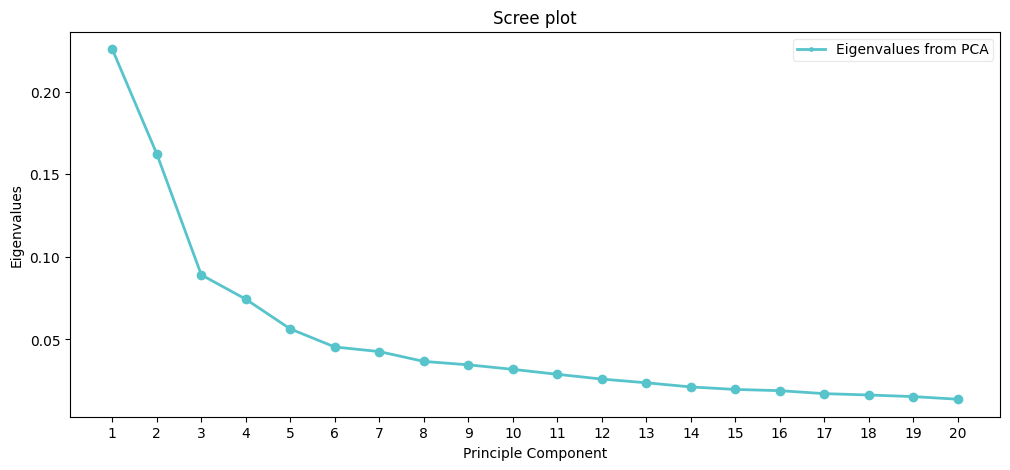

In [ ]:
#　図の枠組みを作る/Create a diagram framework
fig = plt.figure(figsize=(12,5))

plt.plot(["{}".format(x + 1) for x in range(len(df.columns))], evr, 'ro-', linewidth=2, color="#57C4CC")

# 図のタイトル/Figure title
plt.title('Scree plot')

# 図のx軸、y軸ラベル/Figure x-axis and y-axis labels
plt.xlabel('Principle Component')
plt.ylabel('Eigenvalues')

# レジェンドを追加　PCAによる固有値/Add Legend Eigenvalues from PCA
leg = plt.legend(['Eigenvalues from PCA'], loc='best', borderpad=0.3,
                 shadow=False,
                 markerscale=0.4)
leg.get_frame().set_alpha(0.4)
plt.show()

因子分析
* モデルを生成し因子得点を算出します。
* **因子得点**とは各因子ごとの各個体（対象者）のスコアを表します。
---
factor analysis
* Generate a model and calculate factor scores.
* **Factor scores** represent the score of each individual (subject) for each factor.

fa.fit_transform
* Fit to data, then transform it.
* reference: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.FactorAnalysis.html

In [ ]:
# sklearnのFactorAnalysis(因子分析)クラスをインポート/Import sklearn FactorAnalysis class
from sklearn.decomposition import FactorAnalysis as FA

# 因子数を指定/Specify the number of factors
n_components=5

# 因子分析の実行/Perform factor analysis
fa = FA(n_components, max_iter=5000) # モデルを定義/Define model
fitted = fa.fit_transform(z) # fitとtransformを一括処理/Batch processing of fit and transform

print(fitted)
print(fitted.shape)

[[ 0.31000162 -0.32379055  0.38181452 -0.11005612 -0.54475054]
 [ 0.16897048  0.05122829  0.29687021 -0.59834119 -0.16084195]
 [-0.03502552 -0.77418038  0.63605771 -0.84928577  0.27077389]
 ...
 [-0.08083271 -0.27170355  0.46304298 -0.05394314 -0.4293513 ]
 [-0.21093764  1.35379514 -0.10053568  0.03737797 -0.9515514 ]
 [-0.97006129  1.31048214 -1.16215756 -1.19265582  1.9480843 ]]
(272, 5)


因子負荷量行列を取得
* 生成されたモデルfaに対しcomponents_メソッドで因子負荷量を取得し、.Tで行列を転置して表示します。
* 因子の解釈をやり易いように、行名・列名を付与してデータフレームに変換します。
---
Obtain factor loadings matrix
* Obtain the factor loadings for the generated model fa with the components_ method and transpose the matrix with .T to display them.
* To facilitate interpretation of the factors, convert the data into a data frame by assigning row and column names.

In [ ]:
# 因子の解釈/Interpretation of factors
# 変数Factor_loading_matrixに格納/Stored in variable Factor_loading_matrix
Factor_loading_matrix = fa.components_.T

# データフレームに変換/Converted to data frame
pd.DataFrame(Factor_loading_matrix,
             columns=["第1因子/Factor 1", "第2因子/Factor 2", "第3因子/Factor 3", "第4因子/Factor 4", "第5因子/Factor 5"],
             index=[df.columns])

,第1因子/Factor 1,第2因子/Factor 2,第3因子/Factor 3,第4因子/Factor 4,第5因子/Factor 5
"Basically, I try to be nice to all people.",0.691519,0.117495,0.213516,-0.239118,0.187973
I'm pretty good at pacing myself to get things done on time.,0.618674,0.219078,0.142827,0.209795,0.072856
I really enjoy talking to people.,0.736080,0.013359,0.080278,-0.193717,0.013460
I am not a worrier.,0.527128,-0.107450,-0.556706,-0.150303,-0.009217
I don't want to waste my time daydreaming.,0.404682,0.172081,-0.345373,0.240991,0.340262
Would rather cooperate than compete with others,0.446062,0.293721,0.271092,-0.345229,0.221687
I'm not very meticulous.,-0.137434,0.448931,-0.311400,-0.350794,0.054712
I'm not very jolly.,-0.441127,0.578939,-0.068076,0.159030,0.157979
Often nervous or jumpy,-0.350915,0.555080,0.261186,0.118095,0.124220
"Changes with the environment, unaware of their moods and feelings",-0.075906,0.592986,-0.123402,0.117123,0.132603


In [ ]:
fitted

array([[ 0.31000162, -0.32379055,  0.38181452, -0.11005612, -0.54475054],
       [ 0.16897048,  0.05122829,  0.29687021, -0.59834119, -0.16084195],
       [-0.03502552, -0.77418038,  0.63605771, -0.84928577,  0.27077389],
       ...,
       [-0.08083271, -0.27170355,  0.46304298, -0.05394314, -0.4293513 ],
       [-0.21093764,  1.35379514, -0.10053568,  0.03737797, -0.9515514 ],
       [-0.97006129,  1.31048214, -1.16215756, -1.19265582,  1.9480843 ]])

* 因子負荷量とは、因子分析において得られた共通因子が分析に用いた変数（観測変数）に与える影響の強さを表す値で、観測変数と因子得点との相関係数に相当する。
* －1以上1以下の値をとり、因子負荷量の絶対値が大きいほど、その共通因子と観測変数の間に（正または負の）強い相関があることを示し、観測変数をよく説明する因子であると言える。
* 因子負荷量の絶対値の大きさ、因子負荷量のプラス・マイナスにもとづいて因子の解釈をおこないます。
---
* The factor loadings express the relationship of each variable to the underlying factor.
* -Values between 1 and 1, and larger absolute values of factor loadings indicate a stronger correlation (positive or negative) between the common factor and the observed variable, and thus the factor explains the observed variable better.
* Factor interpretation is based on the absolute magnitude of the factor loadings, plus or minus the factor loadings.

In [ ]:
# big five 理論の5要素/Big five Theory's five elements
factors = ['外向性/extroversion', '調和性/harmonization', '誠実性/integrity', '神経症的傾向/neuroticism', '経験への開放性/Openness to experience']

#　第一因子：外交的、競争、好奇心、努力家、楽天的
#　第二因子：几帳面、陽気、物怖じしない、誰とでも仲良く、先延ばししない、我が道行かない　（調和性＋誠実性）
#　第三因子: 心配性
#　第四因子：親切でない、先延ばししない、常に流される
#　第五因子：好奇心がない、空想ふけたくない
# Factor 1: diplomatic, competitive, curious, hardworking, optimistic
# Factor 2: methodical, cheerful, fearless, gets along with everyone, doesn't procrastinate, doesn't go out of his or her way (harmony + integrity)
# Factor 3: worrier
# Factor 4: unkind, never procrastinates, always drifts
# Factor 5: not curious, not fanciful

散布図行列/scattergram matrix

In [ ]:
df_sdgs = df.iloc[:,30:]
#df_sdgs_renamed = df_sdgs.rename(index={0:SDG1, 1:})
df_fa = pd.DataFrame(fitted, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
df_scatter_plot_matrix = pd.concat([df_fa, df_sdgs], axis=1)
df_scatter_plot_matrix

,PC1,PC2,PC3,PC4,PC5
0,0.310002,-0.323791,0.381815,-0.110056,-0.544751
1,0.168970,0.051228,0.296870,-0.598341,-0.160842
2,-0.035026,-0.774180,0.636058,-0.849286,0.270774
3,0.683486,-0.118702,0.112872,-0.819967,-0.248389
4,0.351026,0.634655,-2.664569,0.027146,-1.360138
...,...,...,...,...,...
267,-1.266609,-2.436666,0.601827,0.388272,-0.153260
268,2.500822,-1.008161,1.412332,0.263661,0.440541
269,-0.080833,-0.271704,0.463043,-0.053943,-0.429351
270,-0.210938,1.353795,-0.100536,0.037378,-0.951551


array([[<Axes: xlabel='PC1', ylabel='PC1'>,
        <Axes: xlabel='PC2', ylabel='PC1'>,
        <Axes: xlabel='PC3', ylabel='PC1'>,
        <Axes: xlabel='PC4', ylabel='PC1'>,
        <Axes: xlabel='PC5', ylabel='PC1'>],
       [<Axes: xlabel='PC1', ylabel='PC2'>,
        <Axes: xlabel='PC2', ylabel='PC2'>,
        <Axes: xlabel='PC3', ylabel='PC2'>,
        <Axes: xlabel='PC4', ylabel='PC2'>,
        <Axes: xlabel='PC5', ylabel='PC2'>],
       [<Axes: xlabel='PC1', ylabel='PC3'>,
        <Axes: xlabel='PC2', ylabel='PC3'>,
        <Axes: xlabel='PC3', ylabel='PC3'>,
        <Axes: xlabel='PC4', ylabel='PC3'>,
        <Axes: xlabel='PC5', ylabel='PC3'>],
       [<Axes: xlabel='PC1', ylabel='PC4'>,
        <Axes: xlabel='PC2', ylabel='PC4'>,
        <Axes: xlabel='PC3', ylabel='PC4'>,
        <Axes: xlabel='PC4', ylabel='PC4'>,
        <Axes: xlabel='PC5', ylabel='PC4'>],
       [<Axes: xlabel='PC1', ylabel='PC5'>,
        <Axes: xlabel='PC2', ylabel='PC5'>,
        <Axes: xlabel='PC3',

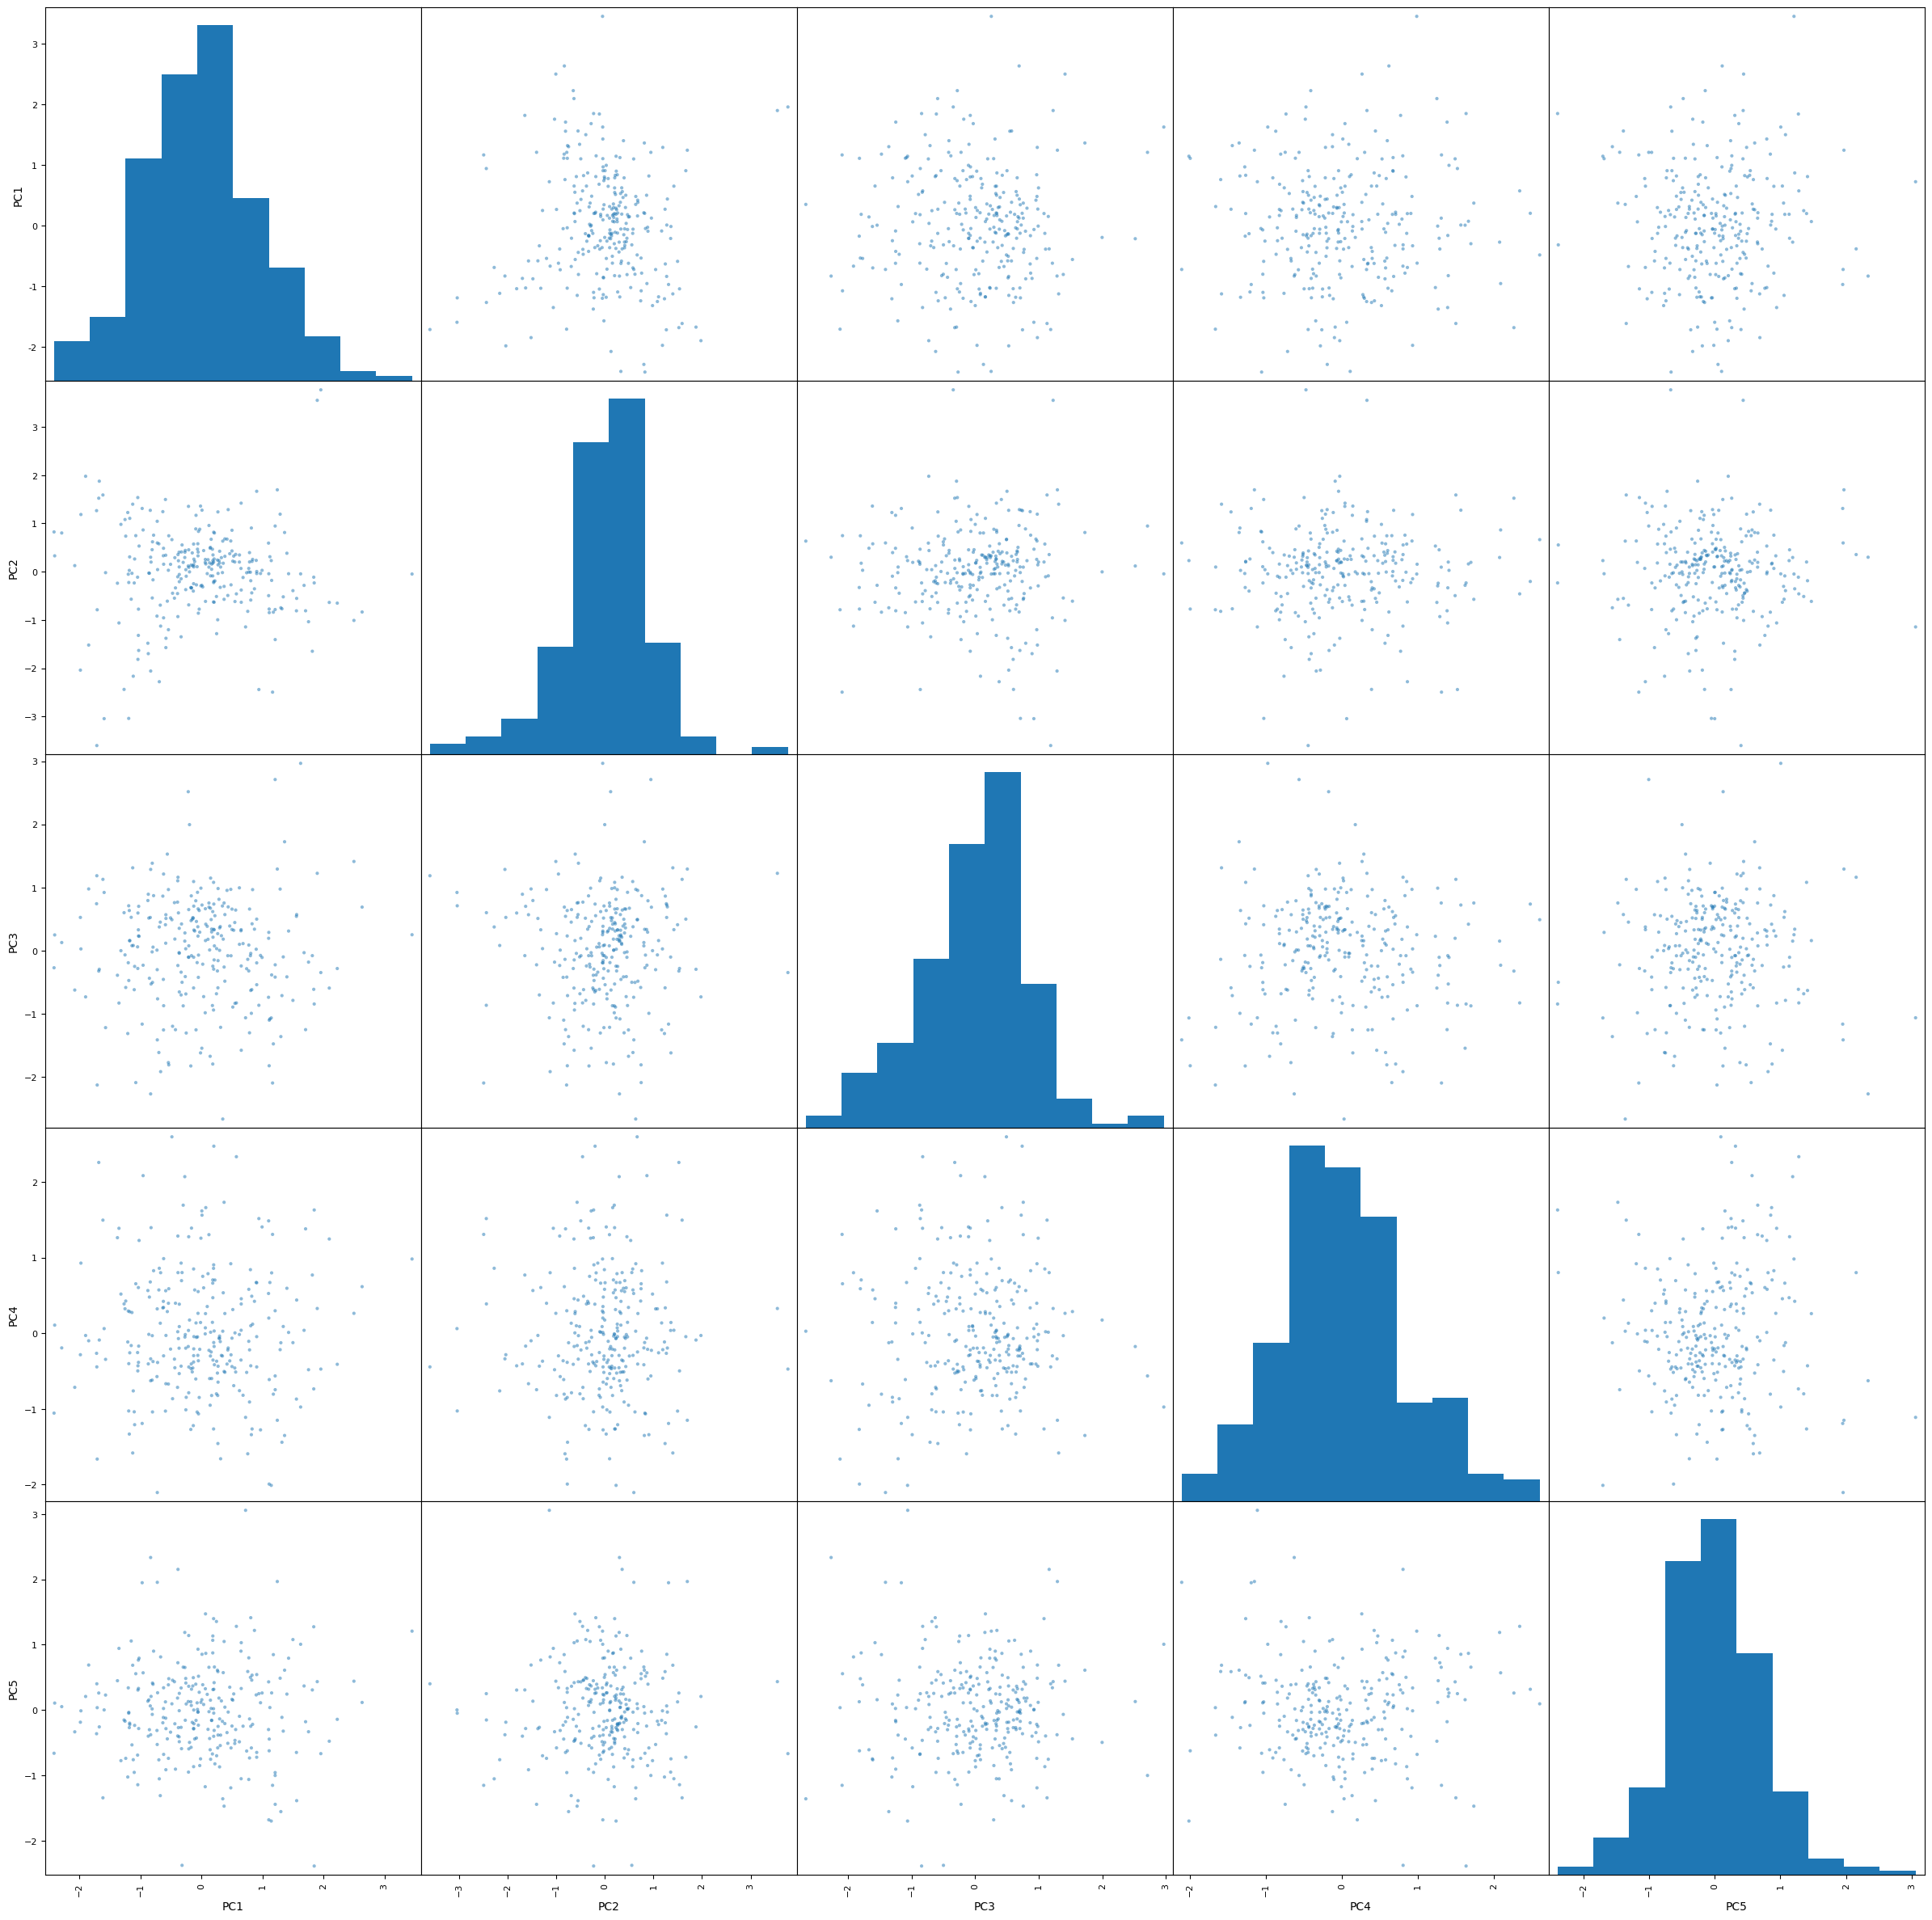

In [ ]:
pd.plotting.scatter_matrix(df_scatter_plot_matrix, figsize=(30,30))